# Analisis de BigWig dataset Plos 2016

In [144]:
from itertools import product
import pyBigWig
import os
import shlex
import subprocess
from pathlib import Path
import re
from collections import defaultdict
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
from scipy.stats import ttest_ind
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests

In [145]:
base_folder = "../assets/plos_2016"

Obs: Los (D) son infectados (Denv) y los (M) son Mock (sanos)

In [154]:
subject = ['D', 'M']
trial = ['1', '2', '3']

bigwigs = {}

for s, t in product(subject, trial):
    bigwigs[f'{s}{t}'] = f"{base_folder}/raw/bigwig/{s}{t}.bigwig"

In [155]:
bigwigs

{'D1': '../assets/plos_2016/raw/bigwig/D1.bigwig',
 'D2': '../assets/plos_2016/raw/bigwig/D2.bigwig',
 'D3': '../assets/plos_2016/raw/bigwig/D3.bigwig',
 'M1': '../assets/plos_2016/raw/bigwig/M1.bigwig',
 'M2': '../assets/plos_2016/raw/bigwig/M2.bigwig',
 'M3': '../assets/plos_2016/raw/bigwig/M3.bigwig'}

## Pruebo cargar un big wig

In [156]:
bigwigs['D1']

'../assets/plos_2016/raw/bigwig/D1.bigwig'

In [157]:
bw = pyBigWig.open(bigwigs['D1'])

In [158]:
bw.header()

{'version': 4,
 'nLevels': 6,
 'nBasesCovered': 3209286105,
 'minVal': 0,
 'maxVal': 46992,
 'sumData': 3240993399,
 'sumSquared': 9669334312766}

- Cromosomas Canónicos: Los conocidos (chr1, chr2, etc.).

- Secuencias Unplaced/Random: Son fragmentos de ADN que se sabe que pertenecen a un cromosoma específico (como el 1) pero cuya ubicación exacta u orientación dentro del cromosoma no se ha podido determinar con total seguridad.

- Contigs "alt": Representan variaciones alternativas de ciertas regiones genómicas que son muy diversas en la población humana

In [161]:
bw.chroms("chr1")

248956422

## De BigWig a BedGraph

In [55]:
for sample, path in bigwigs.items():
    # Creamos el nombre de salida: misma carpeta, misma base, extensión .bedgraph
    out_path = path.replace('.bigwig', '.bedgraph')
    
    print(f"  🚀 Convirtiendo: {sample}...")
    
    try:
        with pyBigWig.open(str(path)) as bw:
            with open(out_path, 'w') as f_out:
                for chrom in bw.chroms():
                    intervals = bw.intervals(chrom)
                    if intervals:
                        for start, end, val in intervals:
                            f_out.write(f"{chrom}\t{start}\t{end}\t{val}\n")
        
        print(f"  ✅ ¡Listo! -> {sample}")
        
    except Exception as e:
        print(f"  ⚠️ Error en {sample}: {e}")

  🚀 Convirtiendo: D1...
  ✅ ¡Listo! -> D1
  🚀 Convirtiendo: D2...
  ✅ ¡Listo! -> D2
  🚀 Convirtiendo: D3...
  ✅ ¡Listo! -> D3
  🚀 Convirtiendo: M1...
  ✅ ¡Listo! -> M1
  🚀 Convirtiendo: M2...
  ✅ ¡Listo! -> M2
  🚀 Convirtiendo: M3...
  ✅ ¡Listo! -> M3


Hay que garantizarnos el orden del bedgraph para su correcto analisis (ordenar por cromosoma y start index)

In [ ]:
mkdir ../assets/plos_2016/bedgraph_sorted

In [ ]:
# 1. Configuración de rutas basada en tu estructura de Drive
out_path = f"{base_folder}/bedgraph_sorted"

base_dir = Path(base_folder)
output_dir = Path(out_path)

# Crear el directorio de salida si no existe (evita errores de 'folder not found')
output_dir.mkdir(parents=True, exist_ok=True)

all_bg = sorted(list(base_dir.glob("*.bedgraph")))
print(f"🔍 Total de archivos a ordenar: {len(all_bg)}")

sorted_paths = {}

for p in all_bg:
    outp = output_dir / f"{p.stem}.sorted.bedgraph"
    
    print(f"🚀 Ordenando: {p.name} -> {outp.name}...")
    
    # Comando sort: -k1,1 (cromosoma alfa) -k2,2n (posición numérica)
    cmd = f"sort -k1,1 -k2,2n {shlex.quote(str(p))} > {shlex.quote(str(outp))}"
    
    try:
        subprocess.check_call(cmd, shell=True)
        sorted_paths[str(p)] = str(outp)
    except subprocess.CalledProcessError as e:
        print(f"❌ Error al ordenar {p.name}: {e}")

print("\n✅ Ejemplo de archivos ordenados:")
for path in list(sorted_paths.values())[:2]:
    print(f"   - {path}")

🔍 Total de archivos a ordenar: 6
🚀 Ordenando: D1.bedgraph -> D1.sorted.bedgraph...
🚀 Ordenando: D2.bedgraph -> D2.sorted.bedgraph...
🚀 Ordenando: D3.bedgraph -> D3.sorted.bedgraph...
🚀 Ordenando: M1.bedgraph -> M1.sorted.bedgraph...
🚀 Ordenando: M2.bedgraph -> M2.sorted.bedgraph...
🚀 Ordenando: M3.bedgraph -> M3.sorted.bedgraph...

✅ Ejemplo de archivos ordenados:
   - ../assets/plos_2016/bedgraph_sorted/D1.sorted.bedgraph
   - ../assets/plos_2016/bedgraph_sorted/D2.sorted.bedgraph


## Anotaciones

In [60]:
!mkdir -p ../assets/plos_2016/refs ../assets/plos_2016/utr3
!curl -L -o ../assets/plos_2016/refs/gencode.v44.annotation.gtf.gz https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.annotation.gtf.gz
!gunzip -f ../assets/plos_2016/refs/gencode.v44.annotation.gtf.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 47.4M  100 47.4M    0     0  3592k      0  0:00:13  0:00:13 --:--:-- 3967k


Descargamos la anotación del genoma humano (GENCODE v44) y vamos a extraer las regiones 3'UTR de los genes que codifican proteínas para crear un archivo de referencia.

Lo que vamos a hacer es, que de la base de referencia, filtrar únicamente los exones y luego, con esos exones, dependiendo de la dirección de la hebra (+ o -) se queda con el máx o min indice de la secuencia, que representa el 3' UTR.

Nota importante: El 3' UTR (la región no traducida al final del gen) casi siempre forma parte del último exón.


*OBS: BED arranca en indice 0 mientras que GTF en 1.*

In [64]:
gtf = f"{base_folder}/refs/gencode.v44.annotation.gtf"
out_bed = f"{base_folder}/utr3/hg38_3UTR_annotation.bed"

PROTEIN_CODING_ONLY = True  # ponelo en False si querés todo

def parse_attrs(s):
    d = {}
    for m in re.finditer(r'(\S+)\s+"([^"]+)"', s):
        d[m.group(1)] = m.group(2)
    return d

exons = defaultdict(list)  # transcript_id -> list of (chrom, start0, end1, strand, gene_id)

with open(gtf) as f:
    for line in f:
        if line.startswith("#"):
            continue
        chrom, src, feat, start, end, score, strand, frame, attrs = line.rstrip("\n").split("\t")
        if feat != "exon":
            continue
        a = parse_attrs(attrs)
        tid = a.get("transcript_id")
        gid = a.get("gene_id")
        if not tid or not gid:
            continue
        if PROTEIN_CODING_ONLY:
            ttype = a.get("transcript_type") or a.get("transcript_biotype") or ""
            if ttype != "protein_coding":
                continue
        s0 = int(start) - 1
        e1 = int(end)
        exons[tid].append((chrom, s0, e1, strand, gid))

print("Transcripts:", len(exons))

with open(out_bed, "w") as out:
    for tid, xs in exons.items():
        strand = xs[0][3]
        gid = xs[0][4]
        if strand == "+":
            last = max(xs, key=lambda t: t[2])  # max end
        else:
            last = min(xs, key=lambda t: t[1])  # min start
        chrom, s0, e1, strand, gid = last[0], last[1], last[2], last[3], last[4]
        out.write(f"{chrom}\t{s0}\t{e1}\t{gid}|{tid}\t0\t{strand}\n")

print("Wrote:", out_bed)

Transcripts: 89067
Wrote: ../assets/plos_2016/utr3/hg38_3UTR_annotation.bed


In [66]:
!head -n 3 ../assets/plos_2016/utr3/hg38_3UTR_annotation.bed

chr1	69036	71585	ENSG00000186092.7|ENST00000641515.2	0	+
chr1	450739	451678	ENSG00000284733.2|ENST00000426406.4	0	-
chr1	685715	686654	ENSG00000284662.2|ENST00000332831.5	0	-


Ahora necesitamos alinear el coverage del begrapgh

In [71]:
ctrl_dir  = os.path.join(base_dir, "NS5 ctl")
treat_dir = os.path.join(base_dir, "NS5 2xNLS ctl")

def list_bedgraphs(folder):
    return sorted(glob.glob(os.path.join(folder, "**", "*.bedgraph"), recursive=True))

ctrl_files  = ['M1', 'M2', 'M3']
treat_files = ['D1', 'D2', 'D3']

# usar sorted si lo generaste:
def sorted_version(p):
    return f"{base_folder}/bedgraph_sorted/{Path(p).stem}.sorted.bedgraph"

ctrl_use  = [sorted_version(p) for p in ctrl_files]
treat_use = [sorted_version(p) for p in treat_files]

def sample_id(p, prefix):
    name = re.sub(r'[\W_]+', '_', Path(p).stem).strip('_')
    return f"{prefix}_{name}"

samplesheet = f"{base_folder}/Aligned_Coverage_bedgraph.txt"
with open(samplesheet, "w") as f:
    for p in ctrl_use:
        f.write(f"{sample_id(p,'CTRL')}\t{p}\n")
    for p in treat_use:
        f.write(f"{sample_id(p,'TREAT')}\t{p}\n")

print("Wrote:", samplesheet)


Wrote: ../assets/plos_2016/Aligned_Coverage_bedgraph.txt


## Dapars config

In [72]:
config_dir = f"{base_folder}/dapars2_run"
os.makedirs(config_dir, exist_ok=True)

config_path = os.path.join(config_dir, "dapars2_config.txt")
result_dir  = os.path.join(config_dir, "results")
os.makedirs(result_dir, exist_ok=True)

annot_3utr_bed = f"{base_folder}/utr3/hg38_3UTR_annotation.bed"

cfg = f"""Aligned_Wig_files={samplesheet}
Annotated_3UTR={annot_3utr_bed}
Output_directory={result_dir}
Group1_Tissue=CTRL
Group2_Tissue=TREAT
Num_Threads=4
Coverage_threshold=30
FDR_cutoff=0.05
PDUI_cutoff=0.2
Fold_change_cutoff=0.59
"""
open(config_path,"w").write(cfg)
print(cfg)
print("Config:", config_path)

Aligned_Wig_files=../assets/plos_2016/Aligned_Coverage_bedgraph.txt
Annotated_3UTR=../assets/plos_2016/utr3/hg38_3UTR_annotation.bed
Output_directory=../assets/plos_2016/dapars2_run/results
Group1_Tissue=CTRL
Group2_Tissue=TREAT
Num_Threads=4
Coverage_threshold=30
FDR_cutoff=0.05
PDUI_cutoff=0.2
Fold_change_cutoff=0.59

Config: ../assets/plos_2016/dapars2_run/dapars2_config.txt


In [ ]:
# Clone DaPars2
!cd ../libs
!rm -rf DaPars2
!git clone https://github.com/3UTR/DaPars2.git

In [ ]:
DAPARS = f"{base_folder}/DaPars2/src/Dapars2_Multi_Sample.py"
CONFIG = f"{base_folder}/dapars2_run/dapars2_config.txt"
BG_GLOB = f"{base_folder}/bedgraph_sorted/*.sorted.bedgraph"   # donde dejaste los sorted

# Cromosomas presentes en los bedgraph (rápido y robusto)
cmd = f"cut -f1 {BG_GLOB} | sort -u"
chroms = subprocess.check_output(cmd, shell=True, text=True).strip().splitlines()

print("Chroms detectados:", chroms)
assert chroms, "No pude detectar cromosomas. Revisá BG_GLOB."

In [80]:
BG_GLOB = f"{base_folder}/bedgraph_sorted/*.sorted.bedgraph"

bg_files = sorted(glob.glob(BG_GLOB))
assert bg_files, f"No encuentro bedgraphs en {base_folder}/bedgraph_sorted/"

def sample_id_from_bg(p):
    # ejemplo: Galaxy101_bamCoverage_on_dataset_100.sorted.bedgraph -> Galaxy101_bamCoverage_on_dataset_100
    s = Path(p).name
    s = s.replace(".sorted.bedgraph","").replace(".bedgraph","")
    s = re.sub(r'[\W_]+', '_', s).strip('_')
    return s

def bedgraph_area(path):
    total = 0.0
    with open(path) as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            chrom, start, end, val = line.rstrip("\n").split("\t")
            start = int(start); end = int(end); val = float(val)
            total += (end - start) * val
    return total

# 1) sequencing depth proxy
depth_file = f"{base_folder}/dapars2_run/sequencing_depth.txt"
os.makedirs(f"{base_folder}/dapars2_run", exist_ok=True)

depths = []
for p in bg_files:
    sid = sample_id_from_bg(p)
    d = bedgraph_area(p)
    depths.append((sid, d))

with open(depth_file, "w") as out:
    for sid, d in depths:
        out.write(f"{sid}\t{d}\n")

print("Wrote:", depth_file)
print(depths[:2])


Wrote: ../assets/plos_2016/dapars2_run/sequencing_depth.txt
[('D1', 3240993400.6756206), ('D2', 3242392284.752619)]


## Otra config que no se que es

In [82]:
annot_3utr_bed = f"{base_folder}/utr3/hg38_3UTR_annotation.bed"   # el que generaste
out_dir = f"{base_folder}/dapars2_run/results"
os.makedirs(out_dir, exist_ok=True)

# comma-separated list (sin txt intermedio)
aligned_wigs = ",".join(bg_files)

config_path = f"{base_folder}/dapars2_run/dapars2_config.txt"

#### NOTAAA !!! LIBERTAD CREATIVA CAMBIO "NS5_vs_NS5_2xNLS" POR M_vs_D 

cfg = f"""# DaPars2 config
Annotated_3UTR={annot_3utr_bed}
Aligned_Wig_files={aligned_wigs}
Output_directory={out_dir}
Output_result_file=M_vs_D
Coverage_threshold=30
Num_Threads=4
sequencing_depth_file={depth_file}
"""

open(config_path, "w").write(cfg)
print("Wrote:", config_path)
print(cfg[:600], "...\n")

Wrote: ../assets/plos_2016/dapars2_run/dapars2_config.txt
# DaPars2 config
Annotated_3UTR=../assets/plos_2016/utr3/hg38_3UTR_annotation.bed
Aligned_Wig_files=../assets/plos_2016/bedgraph_sorted/D1.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/D2.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/D3.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/M1.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/M2.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/M3.sorted.bedgraph
Output_directory=../assets/plos_2016/dapars2_run/results
Output_result_file=M_vs_D
Coverage_threshold=30
Num_Threads=4
sequencing_depth_file=../assets/plos_2016/dapars2_r ...



In [ ]:
BG_GLOB = f"{base_folder}/bedgraph_sorted/*.sorted.bedgraph"
cmd = f"cut -f1 {BG_GLOB} | sort -u"
chroms = subprocess.check_output(cmd, shell=True, text=True).strip().splitlines()

# opcional: filtrar canon hg38
canon = {f"chr{i}" for i in range(1,23)} | {"chrX","chrY"}
chroms = [c for c in chroms if c in canon]

chr_list_path = f"{base_folder}/dapars2_run/chr_list.txt"
with open(chr_list_path, "w") as f:
    f.write("\n".join(chroms) + "\n")

print("Chroms:", chroms)
print("Wrote:", chr_list_path)

In [85]:
#Fix intgrer coverage
BG_GLOB = f"{base_folder}/bedgraph_sorted/*.sorted.bedgraph"
bg_files = sorted(glob.glob(BG_GLOB))
assert bg_files

def bedgraph_area(path):
    total = 0.0
    with open(path) as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            chrom, start, end, val = line.rstrip("\n").split("\t")
            start = int(start); end = int(end); val = float(val)
            total += (end - start) * val
    return total

depth_file = f"{base_folder}/dapars2_run/sequencing_depth.txt"
os.makedirs(f"{base_folder}/dapars2_run", exist_ok=True)

with open(depth_file, "w") as out:
    for p in bg_files:
        sid = sample_id_from_bg(p)
        d = bedgraph_area(p)
        out.write(f"{sid}\t{int(round(d))}\n")  # <-- clave: int

print("Wrote:", depth_file)
!head -n 6 /content/dapars2_run/sequencing_depth.txt


Wrote: ../assets/plos_2016/dapars2_run/sequencing_depth.txt
head: /content/dapars2_run/sequencing_depth.txt: No such file or directory


In [93]:
import multiprocessing
import os

# Forzamos el método de inicio a 'fork' para evitar el error de 'spawn' en Mac
try:
    multiprocessing.set_start_method('fork', force=True)
    print("✅ Método multiprocessing configurado como 'fork'")
except RuntimeError:
    print("⚠️ El método ya estaba configurado.")

# Desactivamos una seguridad adicional de macOS que a veces bloquea el fork
os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"


✅ Método multiprocessing configurado como 'fork'


Tuve que comentar esta parte para que ande en mac

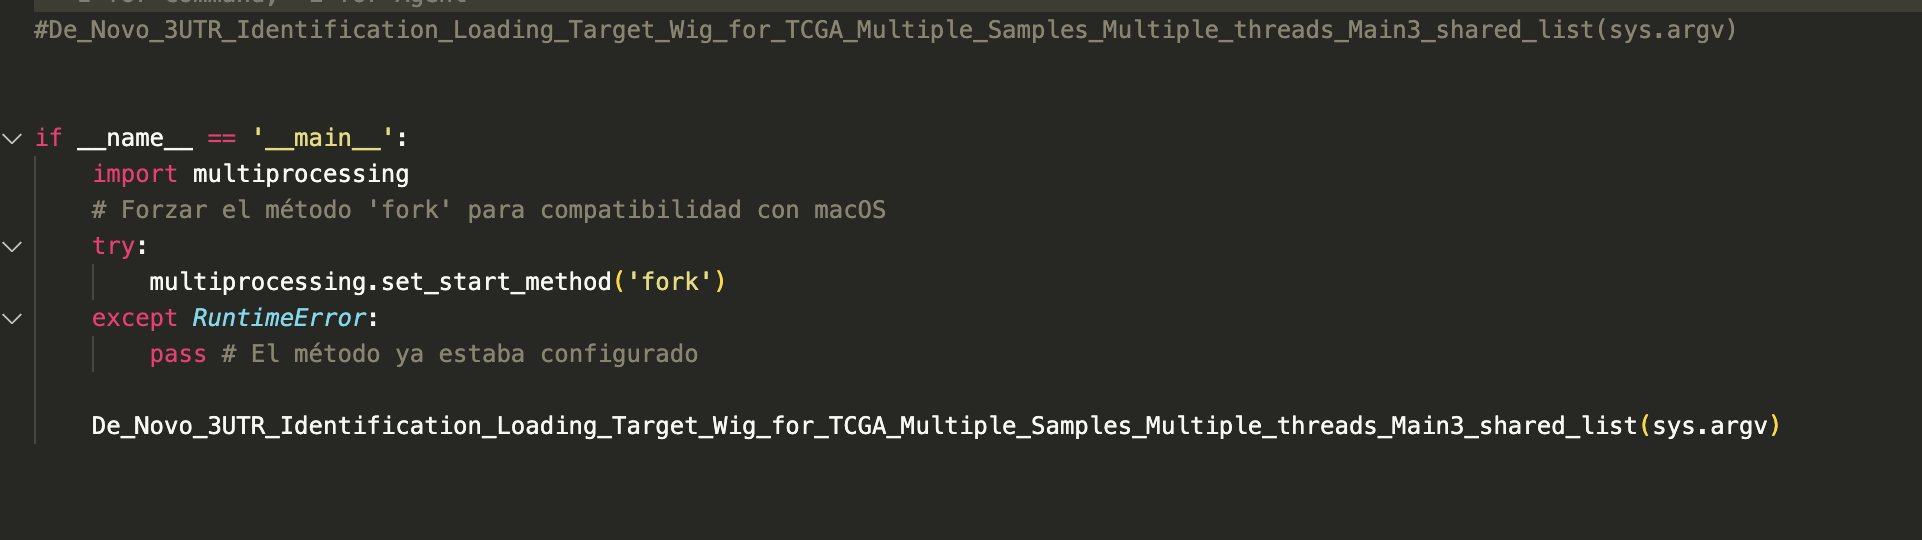

In [ ]:
!python ../libs/DaPars2/src/DaPars2_Multi_Sample_Multi_Chr.py \
    ../assets/plos_2016/dapars2_run/dapars2_config.txt \
    ../assets/plos_2016/dapars2_run/chr_list.txt

In [ ]:
!cat ../assets/plos_2016/dapars2_run/results_chr1/M_vs_D_result_temp.chr1.txt

In [100]:
base = f"{base_folder}/dapars2_run"
files = sorted(glob.glob(os.path.join(base, "results_chr*", "M_vs_D_result_temp.chr*.txt")))
print("Found:", len(files))
assert files, "No encontré result_temp.chr*.txt"

dfs = []
for f in files:
    df = pd.read_csv(f, sep="\t")
    df["source_file"] = os.path.basename(f)
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
out_merged = f"{base_folder}/dapars2_run/NS5_vs_NS5_2xNLS_allchr.tsv"
all_df.to_csv(out_merged, sep="\t", index=False)
print("Wrote:", out_merged, "rows:", all_df.shape[0], "cols:", all_df.shape[1])

all_df.head(3)

Found: 24
Wrote: ../assets/plos_2016/dapars2_run/NS5_vs_NS5_2xNLS_allchr.tsv rows: 20932 cols: 11


,Gene,fit_value,Predicted_Proximal_APA,Loci,../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/D3.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M3.sorted_PDUI,source_file
0,ENSG00000188976.11|ENST00000327044.7,139.5,944550,chr1:944202-944800,0.74,0.83,0.72,0.69,0.75,0.62,M_vs_D_result_temp.chr1.txt
1,ENSG00000187608.10|ENST00000624697.4,199.7,1014250,chr1:1013983-1014540,0.81,0.68,0.86,NaN,NaN,NaN,M_vs_D_result_temp.chr1.txt
2,ENSG00000187608.10|ENST00000624652.1,194.3,1014250,chr1:1013983-1014435,0.83,0.71,0.93,NaN,NaN,NaN,M_vs_D_result_temp.chr1.txt


In [102]:
ctrl_keys  = ["M1", "M2", "M3"]
treat_keys = ["D1", "D2", "D3"]

# columnas PDUI (son las que arrancan con /content/bedgraph_sorted/...)
pdui_cols = [c for c in all_df.columns if c.endswith("_PDUI")]

def pick_cols(keys):
    cols = []
    for c in pdui_cols:
        if any(k in c for k in keys):
            cols.append(c)
    return cols

ctrl_cols  = pick_cols(ctrl_keys)
treat_cols = pick_cols(treat_keys)

print("CTRL cols:", len(ctrl_cols), ctrl_cols[:2])
print("TREAT cols:", len(treat_cols), treat_cols[:2])
assert len(ctrl_cols)==3 and len(treat_cols)==3, "No pude identificar 3+3 columnas PDUI"

res = all_df.copy()

# stats básicos
res["mean_CTRL"]  = res[ctrl_cols].mean(axis=1)
res["mean_TREAT"] = res[treat_cols].mean(axis=1)
res["delta_PDUI"] = res["mean_TREAT"] - res["mean_CTRL"]
res["abs_delta"]  = res["delta_PDUI"].abs()

# colapsar a nivel gene_id (opcional): quedate con el transcripto con mayor |Δ|
res["gene_id"] = res["Gene"].str.split("|").str[0]
res_gene = (res.sort_values("abs_delta", ascending=False)
              .groupby("gene_id", as_index=False)
              .head(1)
              .reset_index(drop=True))

top10 = res_gene.sort_values("abs_delta", ascending=False).head(10)
top10[["gene_id","Gene","Loci","Predicted_Proximal_APA","mean_CTRL","mean_TREAT","delta_PDUI"]]

CTRL cols: 3 ['../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI', '../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI']
TREAT cols: 3 ['../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI', '../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI']


,gene_id,Gene,Loci,Predicted_Proximal_APA,mean_CTRL,mean_TREAT,delta_PDUI
0,ENSG00000204463.14,ENSG00000204463.14|ENST00000438149.5,chr6:31642831-31643115,31642950,0.680000,0.230000,-0.450000
1,ENSG00000134330.19,ENSG00000134330.19|ENST00000470914.5,chr2:9488146-9489742,9488350,0.530000,0.953333,0.423333
2,ENSG00000241258.7,ENSG00000241258.7|ENST00000431089.6,chr7:66152207-66152870,66152600,0.440000,0.790000,0.350000
3,ENSG00000128487.19,ENSG00000128487.19|ENST00000679801.1,chr17:20313975-20314685,20314400,0.980000,0.640000,-0.340000
4,ENSG00000214967.6,ENSG00000214967.6|ENST00000344087.4,chr16:16393455-16393808,16393700,0.685000,0.990000,0.305000
5,ENSG00000182712.16,ENSG00000182712.16|ENST00000369479.1,chrX:155061627-155061991,155061840,0.773333,0.490000,-0.283333
6,ENSG00000108021.22,ENSG00000108021.22|ENST00000695835.1,chr10:5763028-5763632,5763350,0.620000,0.903333,0.283333
7,ENSG00000050426.16,ENSG00000050426.16|ENST00000553043.1,chr12:51059360-51059867,51059600,0.930000,0.650000,-0.280000
8,ENSG00000131446.17,ENSG00000131446.17|ENST00000512695.1,chr5:180792624-180793097,180792800,0.720000,0.993333,0.273333
9,ENSG00000157637.13,ENSG00000157637.13|ENST00000576151.1,chr17:81246271-81246673,81246500,0.730000,1.000000,0.270000


In [139]:
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*Precision loss occurred in moment calculation.*")

def welch_p(row):
    # Extraemos valores ignorando los NaNs internos de cada grupo
    a = row[ctrl_cols].astype(float).dropna().values
    b = row[treat_cols].astype(float).dropna().values
    
    # Exigimos al menos 2 réplicas válidas por grupo para tener rigor
    if len(a) < 2 or len(b) < 2:
        return np.nan
        
    # Evitamos error si la varianza es cero
    if np.var(a) == 0 and np.var(b) == 0:
        return np.nan
        
    # Calculamos el p-value
    return ttest_ind(a, b, equal_var=False, nan_policy='omit').pvalue
res_gene["p_welch"] = res_gene.apply(welch_p, axis=1)
top10 = res_gene.sort_values("abs_delta", ascending=False).head(10)
top10[["gene_id","Gene","Loci","mean_CTRL","mean_TREAT","delta_PDUI","p_welch"]]


,gene_id,Gene,Loci,mean_CTRL,mean_TREAT,delta_PDUI,p_welch
0,ENSG00000204463.14,ENSG00000204463.14|ENST00000438149.5,chr6:31642831-31643115,0.680000,0.230000,-0.450000,NaN
1,ENSG00000134330.19,ENSG00000134330.19|ENST00000470914.5,chr2:9488146-9489742,0.530000,0.953333,0.423333,0.002718
2,ENSG00000241258.7,ENSG00000241258.7|ENST00000431089.6,chr7:66152207-66152870,0.440000,0.790000,0.350000,NaN
3,ENSG00000128487.19,ENSG00000128487.19|ENST00000679801.1,chr17:20313975-20314685,0.980000,0.640000,-0.340000,NaN
4,ENSG00000214967.6,ENSG00000214967.6|ENST00000344087.4,chr16:16393455-16393808,0.685000,0.990000,0.305000,0.168813
5,ENSG00000182712.16,ENSG00000182712.16|ENST00000369479.1,chrX:155061627-155061991,0.773333,0.490000,-0.283333,NaN
6,ENSG00000108021.22,ENSG00000108021.22|ENST00000695835.1,chr10:5763028-5763632,0.620000,0.903333,0.283333,NaN
7,ENSG00000050426.16,ENSG00000050426.16|ENST00000553043.1,chr12:51059360-51059867,0.930000,0.650000,-0.280000,NaN
8,ENSG00000131446.17,ENSG00000131446.17|ENST00000512695.1,chr5:180792624-180793097,0.720000,0.993333,0.273333,NaN
9,ENSG00000157637.13,ENSG00000157637.13|ENST00000576151.1,chr17:81246271-81246673,0.730000,1.000000,0.270000,NaN


In [126]:
res.columns

Index(['Gene', 'fit_value', 'Predicted_Proximal_APA', 'Loci',
       '../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/D3.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/M3.sorted_PDUI', 'source_file',
       'mean_CTRL', 'mean_TREAT', 'delta_PDUI', 'abs_delta', 'gene_id'],
      dtype='object')

In [141]:
# Inicializamos la columna FDR y calculamos la corrección Benjamini-Hochberg
res_gene["FDR"] = np.nan
valid_mask = res_gene["p_welch"].notna()
res_gene.loc[valid_mask, "FDR"] = multipletests(res_gene.loc[valid_mask, "p_welch"], method='fdr_bh')[1]


# Filtramos solo los genes donde pudimos calcular estadística
df_plot = res_gene.dropna(subset=['FDR', 'delta_PDUI']).copy()

# Calculamos el -log10 del FDR para el eje Y del Volcano Plot
# Sumamos un epsilon (1e-300) para evitar log(0) si hay p-values extremadamente bajos
df_plot['-log10(FDR)'] = -np.log10(df_plot['FDR'] + 1e-300)

Total de genes (p < 0.05 y |Delta| > 0.20): 7
Balance: (array(['Acortados (-)', 'Alargados (+)'], dtype='<U13'), array([1, 6]))


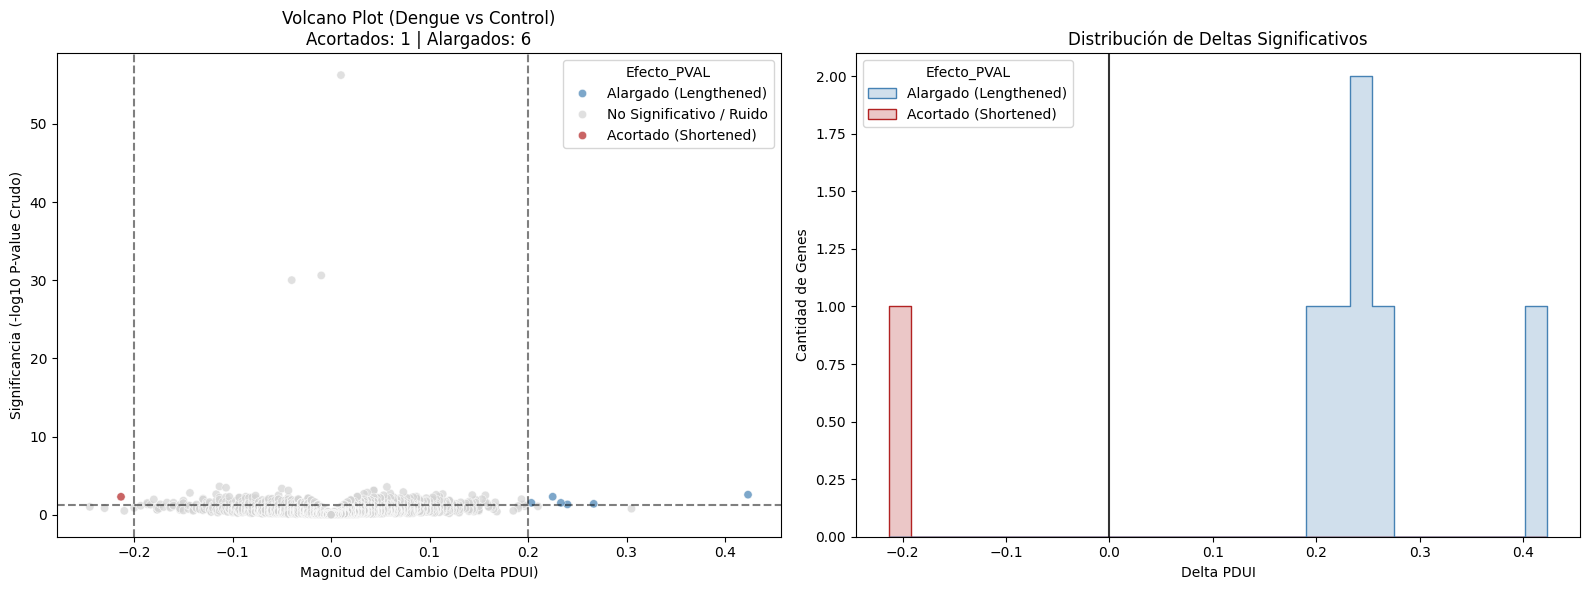

In [ ]:
# 1. Ajustamos los umbrales (Usamos el p-value crudo en vez del FDR)
PVAL_CUTOFF = 0.05
DELTA_CUTOFF = 0.20 

# 2. Exploración rápida
genes_reales = df_plot[(df_plot['p_welch'] < PVAL_CUTOFF) & (df_plot['delta_PDUI'].abs() >= DELTA_CUTOFF)].copy()
print(f"Total de genes (p < 0.05 y |Delta| > 0.20): {len(genes_reales)}")

conteo = np.where(genes_reales['delta_PDUI'] < 0, 'Acortados (-)', 'Alargados (+)')
print("Balance:", np.unique(conteo, return_counts=True))


# Recalculamos el eje Y para que use p_welch
df_plot['-log10(PVAL)'] = -np.log10(df_plot['p_welch'] + 1e-300)

def classify_event_pval(row):
    if row['p_welch'] < PVAL_CUTOFF:
        if row['delta_PDUI'] <= -DELTA_CUTOFF:
            return 'Acortado (Shortened)'
        elif row['delta_PDUI'] >= DELTA_CUTOFF:
            return 'Alargado (Lengthened)'
    return 'No Significativo / Ruido'

df_plot['Efecto_PVAL'] = df_plot.apply(classify_event_pval, axis=1)

n_short = (df_plot['Efecto_PVAL'] == 'Acortado (Shortened)').sum()
n_long = (df_plot['Efecto_PVAL'] == 'Alargado (Lengthened)').sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colores = {'Acortado (Shortened)': 'firebrick', 'Alargado (Lengthened)': 'steelblue', 'No Significativo / Ruido': 'lightgray'}

# --- GRÁFICO 1: VOLCANO PLOT ---
sns.scatterplot(data=df_plot, x='delta_PDUI', y='-log10(PVAL)', hue='Efecto_PVAL', palette=colores, alpha=0.7, ax=ax1)
ax1.axhline(-np.log10(PVAL_CUTOFF), ls='--', color='black', alpha=0.5)
ax1.axvline(-DELTA_CUTOFF, ls='--', color='black', alpha=0.5)
ax1.axvline(DELTA_CUTOFF, ls='--', color='black', alpha=0.5)
ax1.set_title(f'Volcano Plot (Dengue vs Control)\nAcortados: {n_short} | Alargados: {n_long}')
ax1.set_xlabel('Magnitud del Cambio (Delta PDUI)')
ax1.set_ylabel('Significancia (-log10 P-value Crudo)')

# --- GRÁFICO 2: HISTOGRAMA ---
df_sig = df_plot[df_plot['Efecto_PVAL'] != 'No Significativo / Ruido']

if len(df_sig) > 0:
    sns.histplot(data=df_sig, x='delta_PDUI', hue='Efecto_PVAL', palette=colores, element="step", common_norm=False, bins=30, ax=ax2)
else:
    ax2.text(0.5, 0.5, '0 genes superaron el filtro', ha='center', va='center', fontsize=12, color='firebrick', transform=ax2.transAxes)

ax2.axvline(0, ls='-', color='black', alpha=0.8)
ax2.set_title('Distribución de Deltas Significativos')
ax2.set_xlabel('Delta PDUI')
ax2.set_ylabel('Cantidad de Genes')

plt.tight_layout()
plt.show()

## Visualizaciones

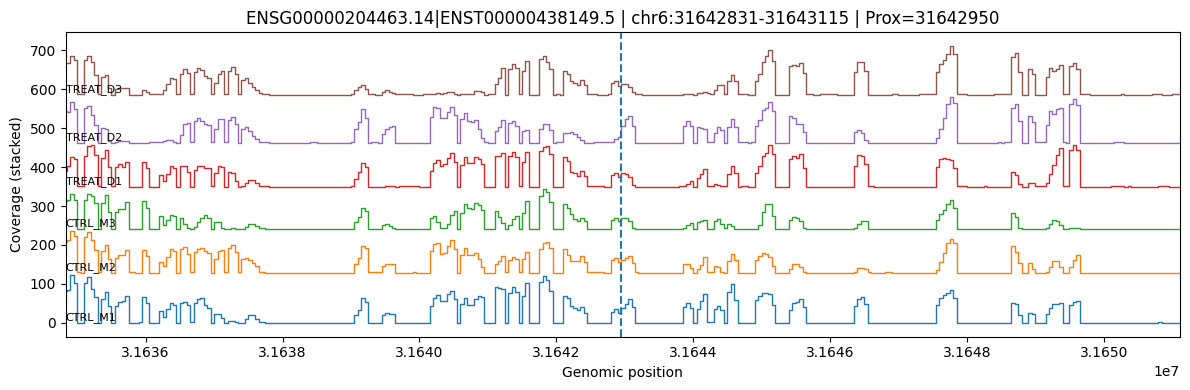

In [ ]:
bg_map = {
  "CTRL_M1": f"{base_folder}/bedgraph_sorted/M1.sorted.bedgraph",
  "CTRL_M2": f"{base_folder}/bedgraph_sorted/M2.sorted.bedgraph",
  "CTRL_M3": f"{base_folder}/bedgraph_sorted/M3.sorted.bedgraph",
  "TREAT_D1":f"{base_folder}/bedgraph_sorted/D1.sorted.bedgraph",
  "TREAT_D2":f"{base_folder}/bedgraph_sorted/D2.sorted.bedgraph",
  "TREAT_D3":f"{base_folder}/bedgraph_sorted/D3.sorted.bedgraph",
}

def parse_loci(loci_str):
    # ejemplo: chr1:1785284-1787053
    chrom, rest = loci_str.split(":")
    s, e = rest.split("-")
    return chrom, int(s), int(e)

def load_bedgraph_region(path, chrom, start, end):
    # lee linealmente; para región chica funciona bien en Colab
    xs = []
    with open(path) as f:
        for line in f:
            c, s, e, v = line.rstrip("\n").split("\t")
            if c != chrom:
                continue
            s = int(s); e = int(e); v = float(v)
            if e < start:
                continue
            if s > end:
                break
            # clip al intervalo solicitado
            s2 = max(s, start)
            e2 = min(e, end)
            xs.append((s2, e2, v))
    return xs

def plot_tracks(gene_label, loci, prox_site, flank=5000, out_png=None):
    chrom, s, e = parse_loci(loci)
    s0 = max(0, s - flank)
    e0 = e + flank

    fig, ax = plt.subplots(figsize=(12, 4))
    y_offset = 0.0

    for name, path in bg_map.items():
        segs = load_bedgraph_region(path, chrom, s0, e0)
        # construir serie escalonada
        X, Y = [], []
        for a,b,v in segs:
            X += [a, b]
            Y += [v, v]
        # shift para apilar tracks (sencillo y legible)
        ax.plot(X, [yy + y_offset for yy in Y], linewidth=1)
        ax.text(s0, y_offset, name, va="bottom", fontsize=8)
        y_offset += (max(Y) if Y else 1.0) + 5

    ax.axvline(int(prox_site), linestyle="--")
    ax.set_title(f"{gene_label} | {loci} | Prox={prox_site}")
    ax.set_xlabel("Genomic position")
    ax.set_ylabel("Coverage (stacked)")
    ax.set_xlim(s0, e0)

    plt.tight_layout()
    if out_png:
        plt.savefig(out_png, dpi=150)
    plt.show()

# plot top1 como prueba
r = top10.iloc[0]
plot_tracks(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000)


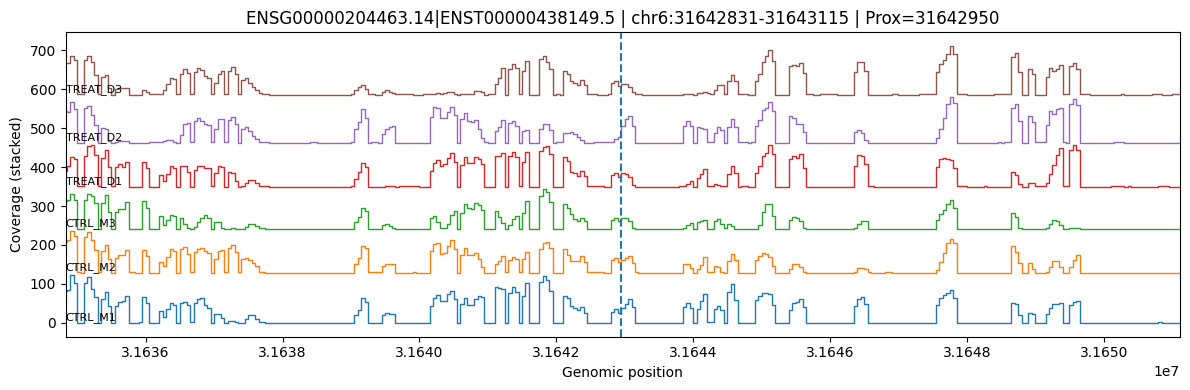

saved: ../assets/plos_2016/top1_ENSG00000204463.14.png


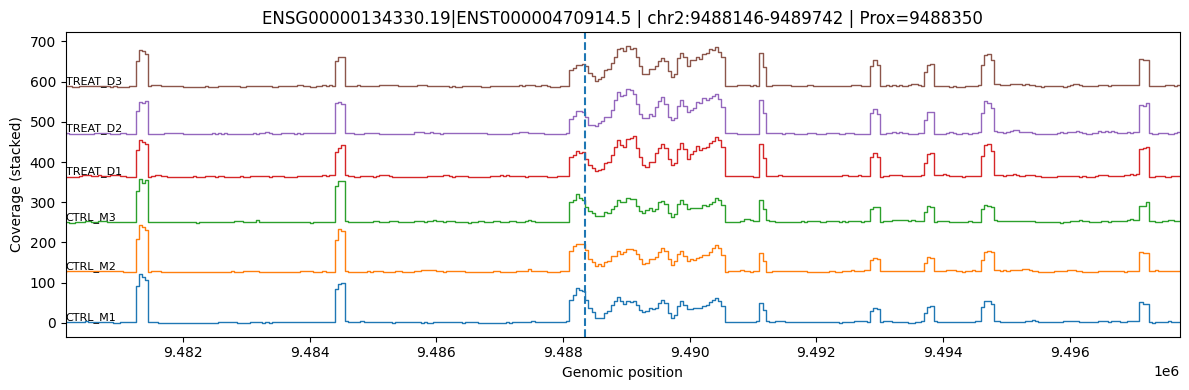

saved: ../assets/plos_2016/top2_ENSG00000134330.19.png


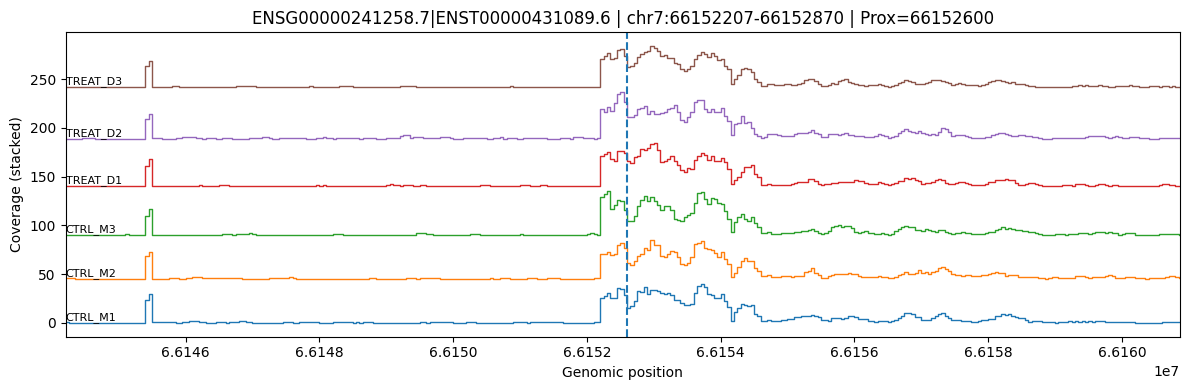

saved: ../assets/plos_2016/top3_ENSG00000241258.7.png


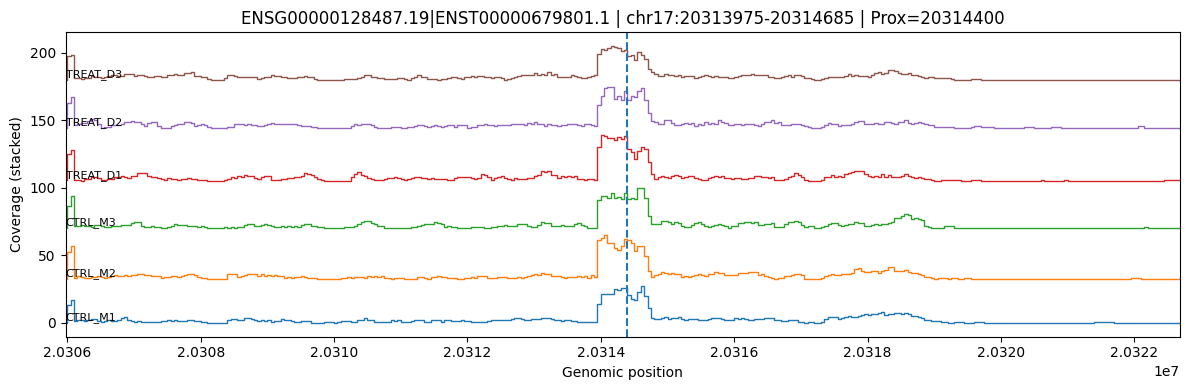

saved: ../assets/plos_2016/top4_ENSG00000128487.19.png


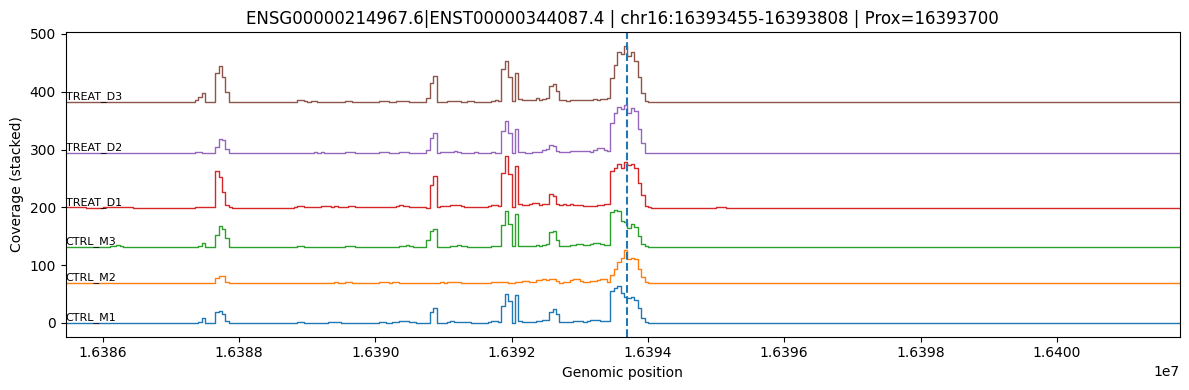

saved: ../assets/plos_2016/top5_ENSG00000214967.6.png


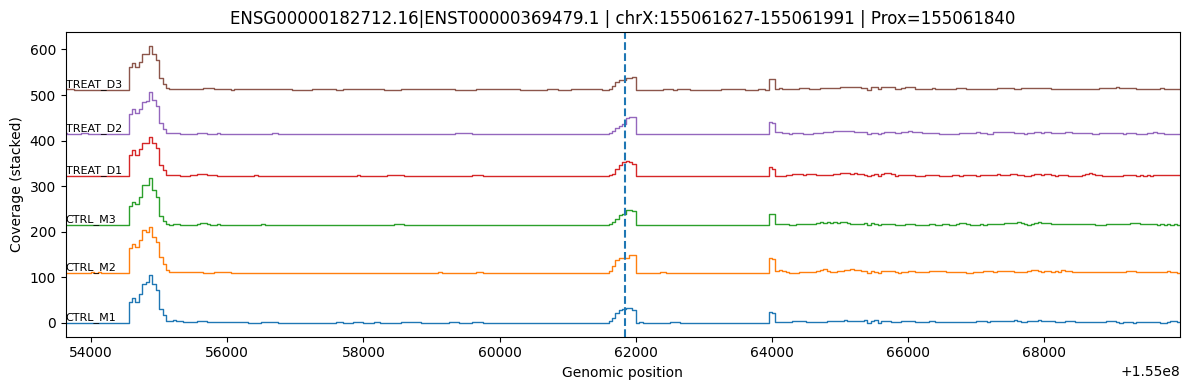

saved: ../assets/plos_2016/top6_ENSG00000182712.16.png


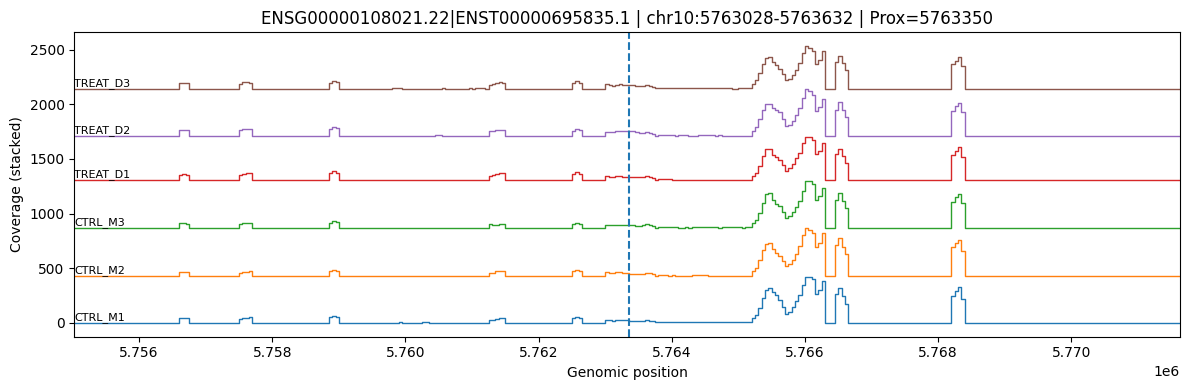

saved: ../assets/plos_2016/top7_ENSG00000108021.22.png


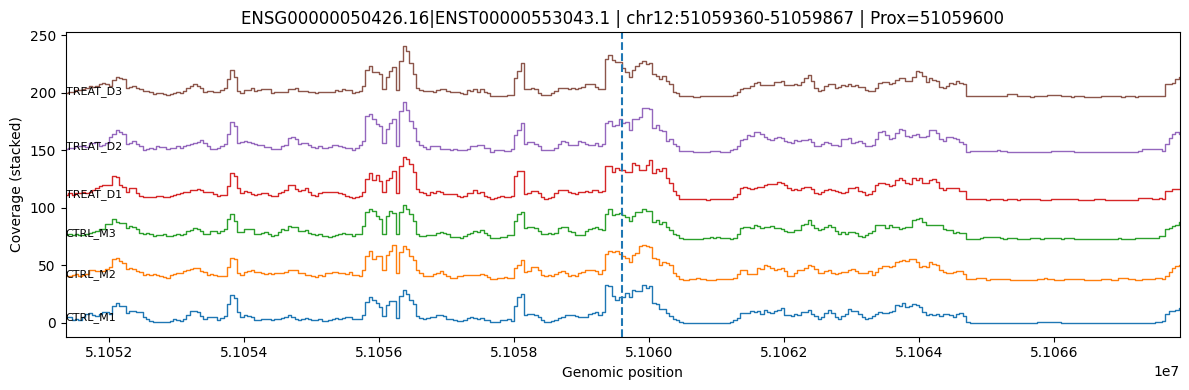

saved: ../assets/plos_2016/top8_ENSG00000050426.16.png


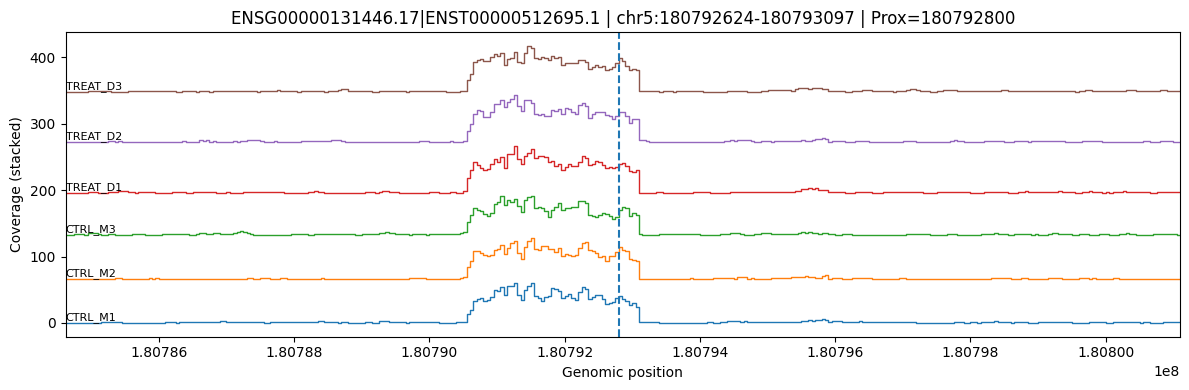

saved: ../assets/plos_2016/top9_ENSG00000131446.17.png


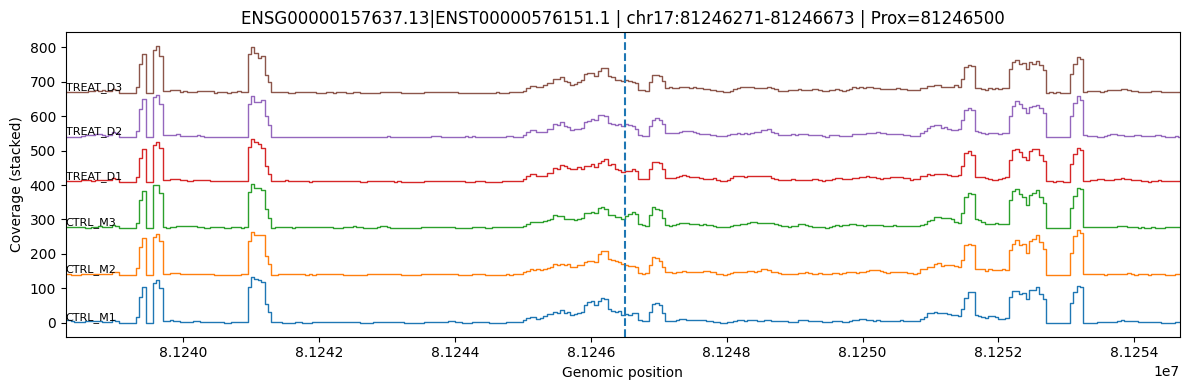

saved: ../assets/plos_2016/top10_ENSG00000157637.13.png


In [ ]:
for i, r in top10.reset_index(drop=True).iterrows():
    out = f"{base_folder}/stack/top{i+1}_{r['gene_id']}.png"
    plot_tracks(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000, out_png=out)
    print("saved:", out)


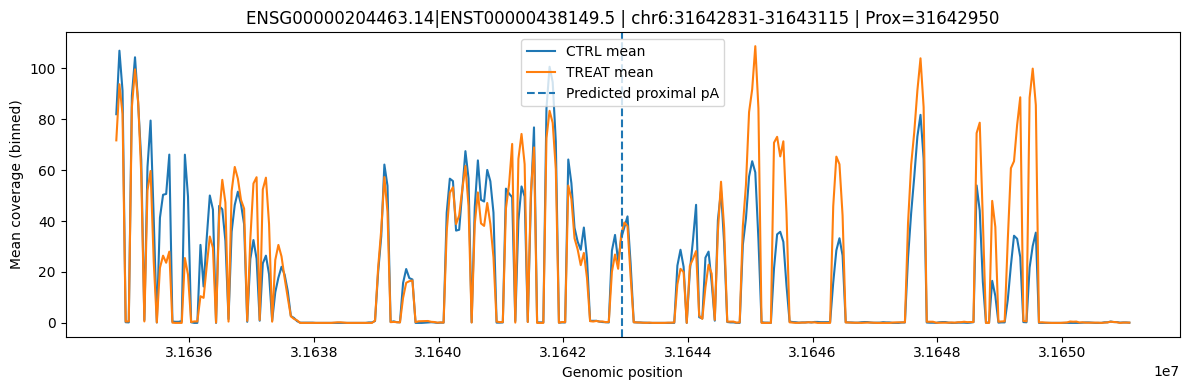

In [114]:
import numpy as np
import matplotlib.pyplot as plt

ctrl_paths = [
    f"{base_folder}/bedgraph_sorted/M1.sorted.bedgraph",
    f"{base_folder}/bedgraph_sorted/M2.sorted.bedgraph",
    f"{base_folder}/bedgraph_sorted/M3.sorted.bedgraph"
]
treat_paths = [
    f"{base_folder}/bedgraph_sorted/D1.sorted.bedgraph",
    f"{base_folder}/bedgraph_sorted/D2.sorted.bedgraph",
    f"{base_folder}/bedgraph_sorted/D3.sorted.bedgraph",
]

def parse_loci(loci_str):
    chrom, rest = loci_str.split(":")
    s, e = rest.split("-")
    return chrom, int(s), int(e)

def load_bedgraph_region(path, chrom, start, end):
    segs = []
    with open(path) as f:
        for line in f:
            c, s, e, v = line.rstrip("\n").split("\t")
            if c != chrom:
                continue
            s = int(s); e = int(e); v = float(v)
            if e < start:
                continue
            if s > end:
                break
            segs.append((max(s, start), min(e, end), v))
    return segs

def segs_to_bins(segs, start, end, step=50):
    """Convierte segmentos bedgraph a vector binned (mean coverage por bin)."""
    n = int(np.ceil((end - start) / step))
    y = np.zeros(n, dtype=float)
    # para cada segmento, rellenar bins intersectados
    for s, e, v in segs:
        b0 = max(0, (s - start) // step)
        b1 = min(n, int(np.ceil((e - start) / step)))
        y[b0:b1] = v
    x = start + np.arange(n) * step
    return x, y

def mean_track(paths, chrom, start, end, step=50):
    ys = []
    x_ref = None
    for p in paths:
        segs = load_bedgraph_region(p, chrom, start, end)
        x, y = segs_to_bins(segs, start, end, step=step)
        if x_ref is None:
            x_ref = x
        ys.append(y)
    return x_ref, np.mean(np.vstack(ys), axis=0)

def plot_mean_ctrl_vs_treat(gene_label, loci, prox_site, flank=8000, step=50, out_png=None):
    chrom, s, e = parse_loci(loci)
    s0 = max(0, s - flank)
    e0 = e + flank

    x, y_ctrl  = mean_track(ctrl_paths,  chrom, s0, e0, step=step)
    _, y_treat = mean_track(treat_paths, chrom, s0, e0, step=step)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, y_ctrl,  label="CTRL mean")
    ax.plot(x, y_treat, label="TREAT mean")
    ax.axvline(int(prox_site), linestyle="--", label="Predicted proximal pA")

    ax.set_title(f"{gene_label} | {loci} | Prox={prox_site}")
    ax.set_xlabel("Genomic position")
    ax.set_ylabel("Mean coverage (binned)")
    ax.legend()
    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=150)
    plt.show()

# ejemplo con el top1 que ya tenías calculado
r = top10.iloc[0]
plot_mean_ctrl_vs_treat(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000, step=50)


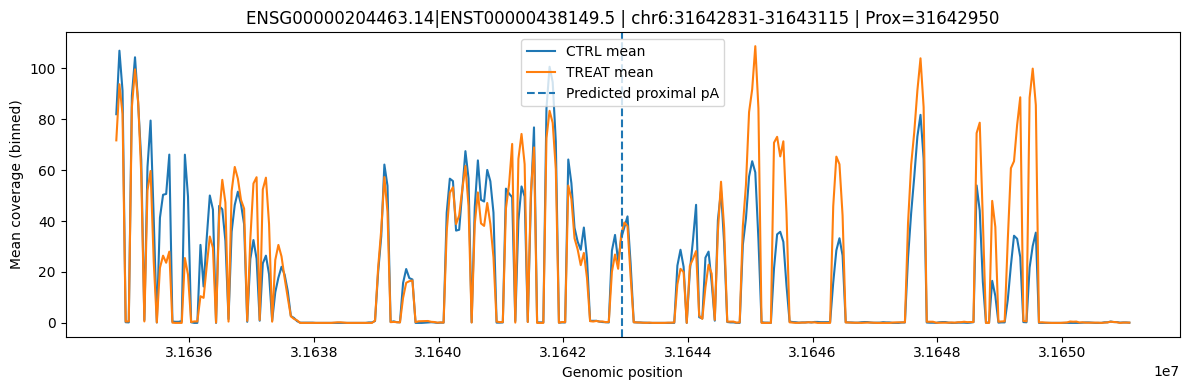

saved: ../assets/plos_2016/mean_track/top1_ENSG00000204463.14_meanCTRLvsTREAT.png


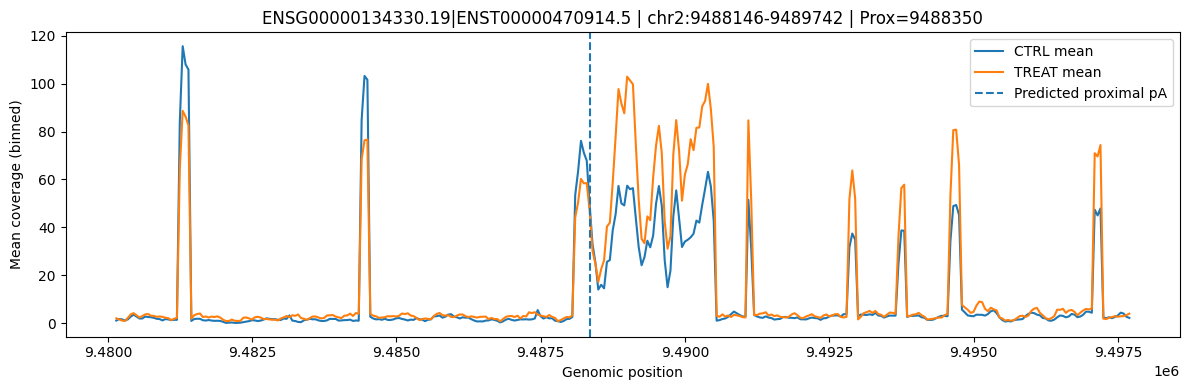

saved: ../assets/plos_2016/mean_track/top2_ENSG00000134330.19_meanCTRLvsTREAT.png


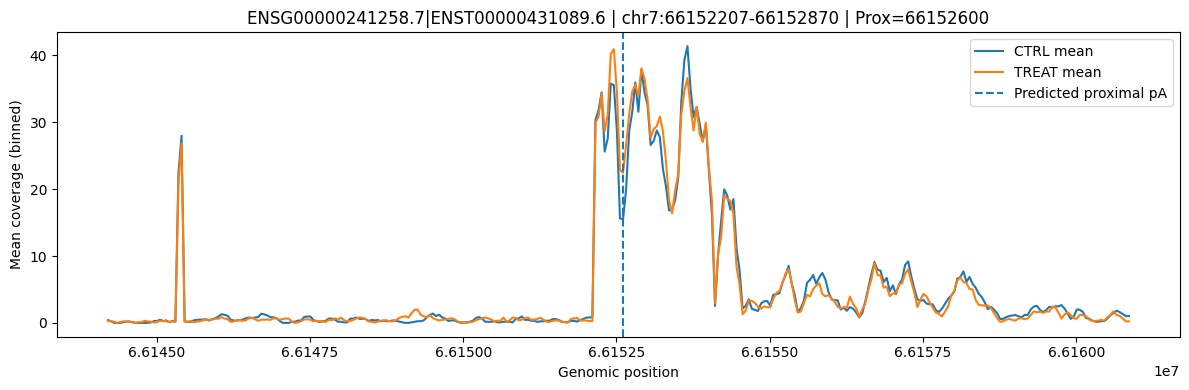

saved: ../assets/plos_2016/mean_track/top3_ENSG00000241258.7_meanCTRLvsTREAT.png


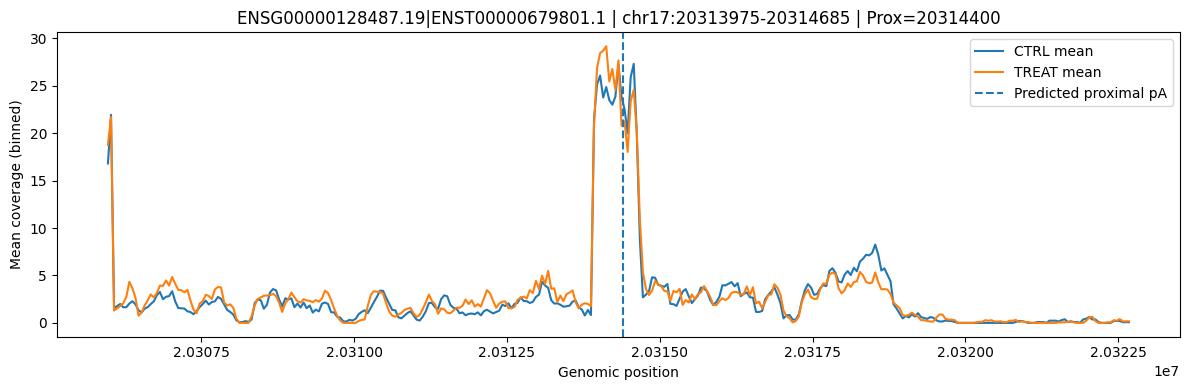

saved: ../assets/plos_2016/mean_track/top4_ENSG00000128487.19_meanCTRLvsTREAT.png


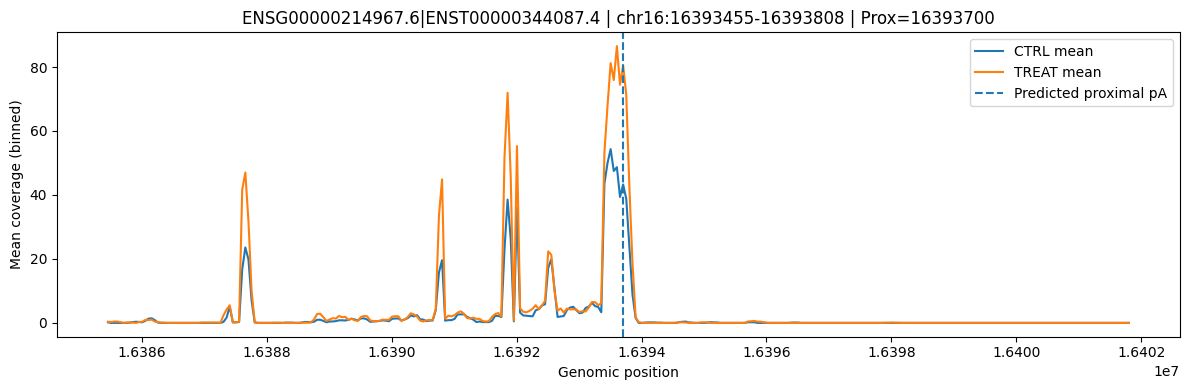

saved: ../assets/plos_2016/mean_track/top5_ENSG00000214967.6_meanCTRLvsTREAT.png


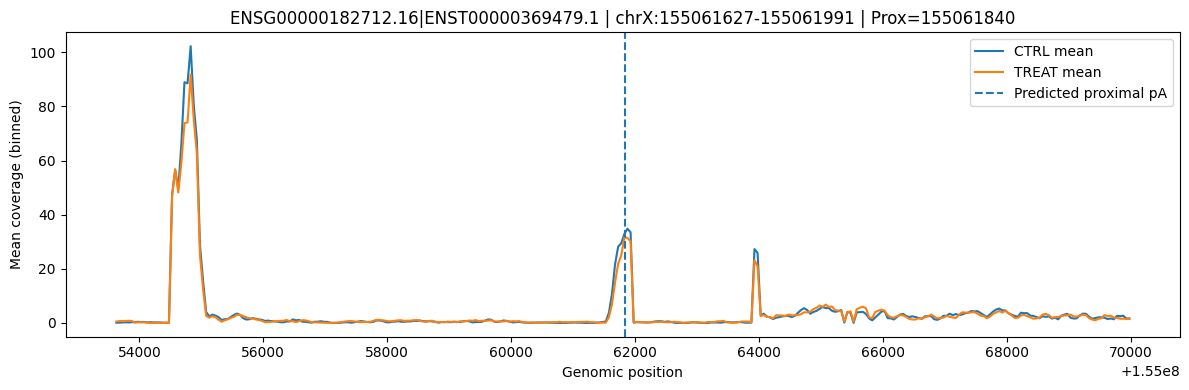

saved: ../assets/plos_2016/mean_track/top6_ENSG00000182712.16_meanCTRLvsTREAT.png


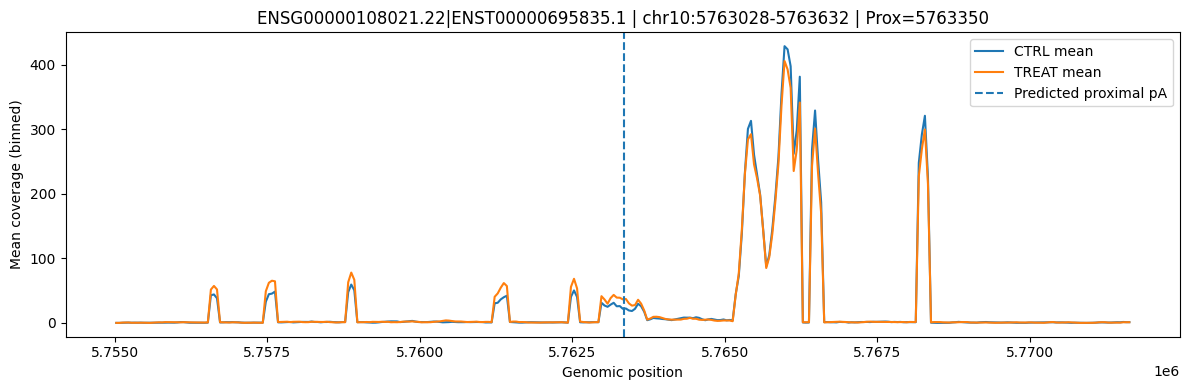

saved: ../assets/plos_2016/mean_track/top7_ENSG00000108021.22_meanCTRLvsTREAT.png


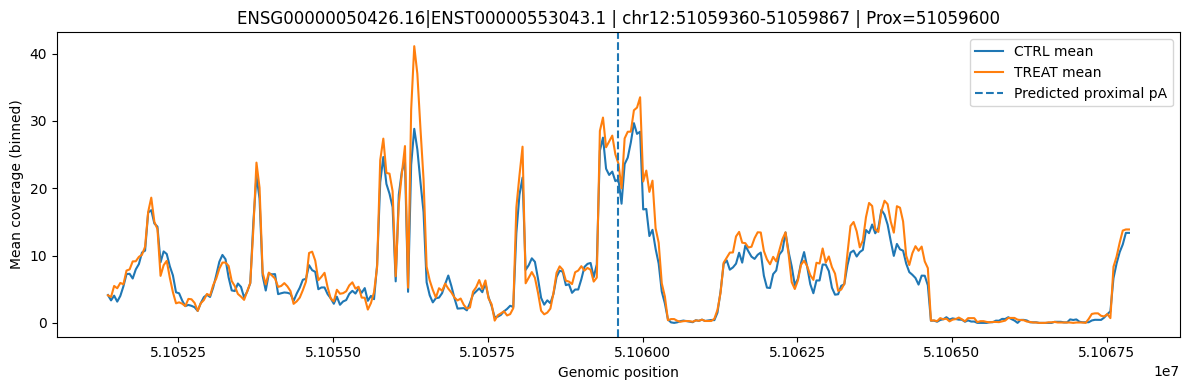

saved: ../assets/plos_2016/mean_track/top8_ENSG00000050426.16_meanCTRLvsTREAT.png


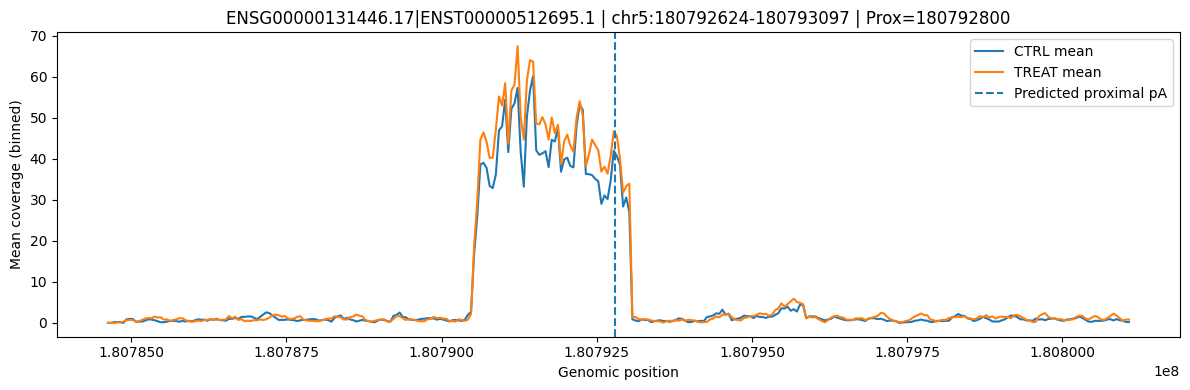

saved: ../assets/plos_2016/mean_track/top9_ENSG00000131446.17_meanCTRLvsTREAT.png


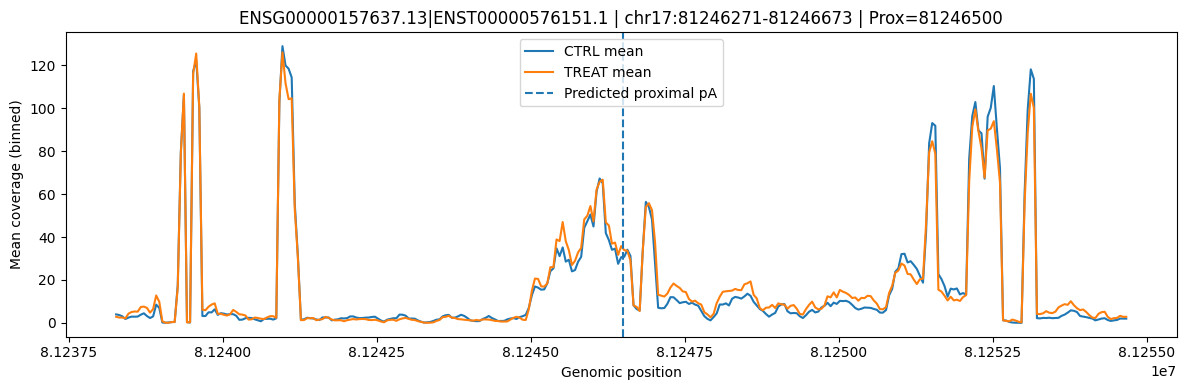

saved: ../assets/plos_2016/mean_track/top10_ENSG00000157637.13_meanCTRLvsTREAT.png


In [116]:
for i, r in top10.reset_index(drop=True).iterrows():
    out = f"{base_folder}/mean_track/top{i+1}_{r['gene_id']}_meanCTRLvsTREAT.png"
    plot_mean_ctrl_vs_treat(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000, step=50, out_png=out)
    print("saved:", out)


## Guardamos resultados

In [120]:
out_root = f"{base_folder}/DaPars2_M_vs_D"

subdirs = [
    "tables",
    "figures",
    "per_chromosome",
    "config",
    "logs"
]

for sd in subdirs:
    Path(f"{out_root}/{sd}").mkdir(parents=True, exist_ok=True)

print("Created:", out_root)

src_base = f"{base_folder}/dapars2_run"

for d in glob.glob(f"{src_base}/results_chr*"):
    dest = f"{out_root}/per_chromosome/{os.path.basename(d)}"
    if os.path.exists(dest):
        shutil.rmtree(dest)
    shutil.copytree(d, dest)

print("Per-chromosome results copied")


# merged all chromosomes
shutil.copy(
    f"{base_folder}/dapars2_run/NS5_vs_NS5_2xNLS_allchr.tsv",
    f"{out_root}/tables/NS5_vs_NS5_2xNLS_allchr.tsv"
)

# top10 ranking
top10_out = f"{out_root}/tables/NS5_vs_NS5_2xNLS_top10_deltaPDUI.tsv"
top10.to_csv(top10_out, sep="\t", index=False)

print("Tables copied")


for fig in glob.glob(f"{base_folder}/top*_meanCTRLvsTREAT.png"):
    shutil.copy(fig, f"{out_root}/figures/{os.path.basename(fig)}")

print("Figures copied")


shutil.copy(
    f"{base_folder}/dapars2_run/dapars2_config.txt",
    f"{out_root}/config/dapars2_config.txt"
)

shutil.copy(
    f"{base_folder}/utr3/hg38_3UTR_annotation.bed",
    f"{out_root}/config/hg38_3UTR_annotation.bed"
)

shutil.copy(
    f"{base_folder}/dapars2_run/chr_list.txt",
    f"{out_root}/config/chr_list.txt"
)

print("Config & annotation copied")

# shutil.copytree(
#     f"{base_folder}/dapars2_run/logs",
#     f"{out_root}/logs",
#     dirs_exist_ok=True
# )

# print("Logs copied")


readme = """\
DaPars2 analysis – NS5 vs NS5 2xNLS (Dengue)

Location:
StartUp/Labo Topografia Transcriptomica/Dengue/DaPars2_NS5_vs_NS5_2xNLS

Genome: hg38 (GRCh38)
Input: bigWig → bedGraph (bamCoverage)
Tool: DaPars2 (multi-chromosome mode)

Folders:
- tables/: merged results and top hits (ΔPDUI)
- figures/: coverage plots (CTRL mean vs TREAT mean)
- per_chromosome/: raw DaPars2 outputs by chromosome
- config/: config, 3'UTR annotation, chromosome list
- logs/: execution logs

Interpretation:
ΔPDUI > 0 → increased distal polyA usage in NS5 2xNLS
ΔPDUI < 0 → proximal shift in NS5 2xNLS

Notes:
- p-values are not reported due to low n and low PDUI variance
- ranking based on absolute ΔPDUI and visual validation
"""

with open(f"{out_root}/README.txt", "w") as f:
    f.write(readme)

print("README written")


Created: ../assets/plos_2016/DaPars2_M_vs_D
Per-chromosome results copied
Tables copied
Figures copied
Config & annotation copied
README written
